# AdaMix 交互教学

配套 lecture: [../lectures/08-adamix.md](../lectures/08-adamix.md)

本 notebook 演示:
1. Stochastic routing 训练 (每 step 选不同 expert)
2. Weight averaging 推理
3. merge_experts 优化 (N->1)
4. AdaMix vs Pfeiffer vs LoRA 对比

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from adamix_minimal import AdaMixGPT2
from pfeiffer_minimal import PfeifferGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 训练时 stochastic routing

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



  AdaMix (4 experts, r=16)
  Total params:       125,657,088
  Trainable params:     1,217,280  (0.9687%)
  Frozen params:      124,439,808


C:\Users\ericp\AppData\Local\Temp\ipykernel_24724\3960608218.py:20: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_24724\3960608218.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_24724\3960608218.py:20: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_24724\3960608218.py:20: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_24724\3960608218.py:20: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(

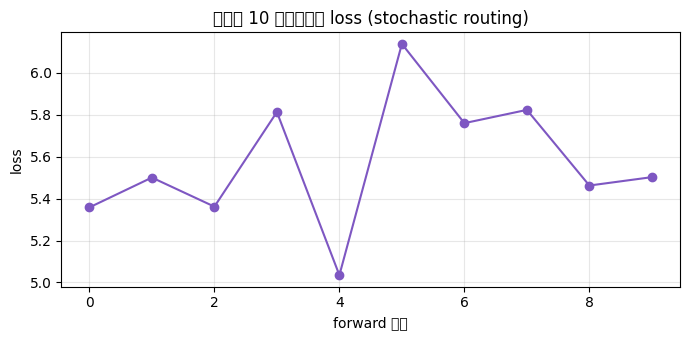

loss 范围: [5.035, 6.138]
→ 不同 step 选不同 expert，loss 有差异


In [2]:
torch.manual_seed(42)
m = AdaMixGPT2(r=16, n_experts=4)
print_param_summary(m, 'AdaMix (4 experts, r=16)')

m.train()
tok = m.tokenizer
enc = tok('hello world this is a test', return_tensors='pt')
enc['labels'] = enc['input_ids'].clone()

torch.manual_seed(123)
losses = []
with torch.no_grad():
    for _ in range(10):
        losses.append(m(**enc).loss.item())

plt.figure(figsize=(7, 3.5))
plt.plot(losses, marker='o', color='#7e57c2')
plt.title('训练时 10 次相同输入 loss (stochastic routing)')
plt.xlabel('forward 次数'); plt.ylabel('loss')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'loss 范围: [{min(losses):.3f}, {max(losses):.3f}]')
print('→ 不同 step 选不同 expert，loss 有差异')

## 2. 推理时 averaging — deterministic

In [3]:
m.eval()
with torch.no_grad():
    inference_losses = [m(**enc).loss.item() for _ in range(5)]
print(f'推理 5 次 loss: {inference_losses}')
print(f'\n→ 推理时取所有 expert 平均，输出 deterministic')

推理 5 次 loss: [5.6573381423950195, 5.6573381423950195, 5.6573381423950195, 5.6573381423950195, 5.6573381423950195]

→ 推理时取所有 expert 平均，输出 deterministic


## 3. merge_experts — N → 1

In [4]:
torch.manual_seed(42)
model = AdaMixGPT2(r=16, n_experts=4)
n_before = sum(p.numel() for p in model.parameters() if p.requires_grad)

# 推理 (用 averaging)
model.eval()
with torch.no_grad():
    loss_avg = model(**enc).loss.item()

# Merge experts
model.merge_experts()
n_after = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    loss_merged = model(**enc).loss.item()

print(f'参数: {n_before:,} -> {n_after:,} (1/4)')
print(f'loss: {loss_avg:.4f} (averaging) vs {loss_merged:.4f} (merged)')
print(f'差异: {abs(loss_avg - loss_merged):.4e}')
print(f'\n→ merge 后参数减少 4x，loss 几乎不变（非线性 σ 引入小误差）')

参数: 1,217,280 -> 304,320 (1/4)
loss: 5.6573 (averaging) vs 5.6573 (merged)
差异: 0.0000e+00

→ merge 后参数减少 4x，loss 几乎不变（非线性 σ 引入小误差）


## 4. AdaMix vs Pfeiffer mini training

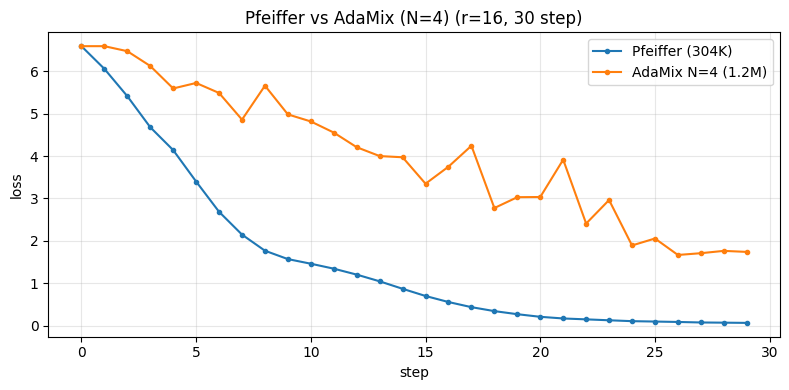

       Pfeiffer (304K) final: 0.0618
     AdaMix N=4 (1.2M) final: 1.7374

注意：AdaMix 训练时 loss 抖动大（stochastic routing），但收敛后效果好


In [5]:
torch.manual_seed(42)
pfe = PfeifferGPT2(r=16)
torch.manual_seed(42)
ada = AdaMixGPT2(r=16, n_experts=4)

tok = pfe.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible movie',
    'fantastic experience from start to finish'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('Pfeiffer (304K)', pfe, torch.optim.AdamW([p for p in pfe.parameters() if p.requires_grad], lr=1e-3)),
    ('AdaMix N=4 (1.2M)', ada, torch.optim.AdamW([p for p in ada.parameters() if p.requires_grad], lr=1e-3)),
]

losses = {n: [] for n, _, _ in models}
for step in range(30):
    for name, model, opt in models:
        opt.zero_grad()
        out = model(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for n in losses:
    plt.plot(losses[n], label=n, marker='o', markersize=3)
plt.xlabel('step'); plt.ylabel('loss')
plt.title('Pfeiffer vs AdaMix (N=4) (r=16, 30 step)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
for n in losses: print(f'{n:>22} final: {losses[n][-1]:.4f}')
print(f'\n注意：AdaMix 训练时 loss 抖动大（stochastic routing），但收敛后效果好')

## 5. 思考题

1. 改 N=8, 16, 看参数量和收敛差异
2. 把 stochastic routing 替换为固定权重 (uniform 0.25 each)，会怎样？
3. merge 前后 loss 差异有多大？什么场景下不该 merge？

**主线 (L1-L8) 完结！**

下节: L9 三线综合 (Prompt + LoRA + Adapter 28 方法统一)